# Example of Agnostic Benchmark application on Regression Task

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import os
import warnings
import sys
warnings.filterwarnings("ignore")

sys.path.insert(0, "../")
import abench

# Task specification

## Component specification

In [2]:
from sklearn.model_selection import RandomizedSearchCV
from abench.src.store import write,read
class regressor:
    def __init__(self,estimator):
        self.estimator = estimator

    def _tuning(self, X, y, params=None,n_esti=100,folds=4,random_state=0):
        """Random_search with sequential k-split

        Args:
            X (array): Features
            y (array): Target
            params (str array, optional): parameter_grid. Defaults to None.
            n_esti (int, optional): Number of grid try . Defaults to 100.
            folds (int, optional): Number of sequential fold. Defaults to 4.
            verbose (int, optional): [description]. Defaults to 0.
        """

        if not(params is None):
            tscv = TimeSeriesSplit(n_splits=folds)
            random_search = RandomizedSearchCV(
                self.estimator,
                param_distributions=params,
                n_iter = n_esti,
                scoring="neg_mean_squared_error",
                n_jobs=8,
                cv=tscv.split(X),
                random_state=random_state,
                verbose=0)
            random_search.fit(X, y)
            self.estimator = random_search.best_estimator_
            
    def fit(self, X, y, **kwarg):
        self.estimator.fit(X, y, **kwarg)

    def predict(self, X, **kwarg):
        output = self.estimator.predict(X, **kwarg)
        return output

    def save(self,storing,keys):
        pass
        
    def load(self,storing,keys):
        pass
    
    def get_params(self):
        params = {'estimator':self.estimator}
        return params

from abench.src.Component import MLComponent
class MLComponent_regressor(MLComponent):
    def __init__(self,regressor,**kwargs):
        if(regressor['parameters'] is None): # If subpart is store as model
            self.regressor = regressor["initializer"]
        else:  # If subpart is store as (initializer,parameters)
            self.regressor = regressor["initializer"](**regressor['parameters'])
    
    def fit(self,X,y,**kwargs):
        self.regressor.fit(X,y)
        
    def predict(self,X,y,**kwargs):
        output = self.regressor.predict(X)
        return(output)
        
    def save(self,storing,keys):
        write(storing,keys,self.regressor)
        
    def load(self,storing,keys):
        self.regressor = read(storing,keys)
    
    def get_params(self):
        params = {'estimator':self.estimator}
        return params

# Metric specification

In [3]:
from abc import ABC, abstractmethod
import numpy as np
from typing import Iterable, Callable

# Exemple of Agnostic benchmark used for regression task 

from sklearn.metrics import mean_absolute_error, mean_squared_error
##################################################################################################
from abench.src.Metric import Encapsulated_metrics as metrics
# Define Encapsulated-metrics using Encapsulated-model ouput as input.

class metrics_mae(metrics):
    def __init__(self):
        self.name = "mae"

    def compute(self, y, output, context, sets=None, **kwarg):
        if(sets is None):
            sets = [np.ones(len(y))==1] 
        print("length of y is : ", len(y)) 
        print("shape of y is : ", y.shape)
        print("length of sets ",len(sets)) 
        y_true = y
        y_pred = output
        perf_res = []
        for set_ in sets:
            print("shape of set_ ",set_.shape)  
            perf_res.append(mean_absolute_error(y_pred[set_], y_true[set_]))
        if(len(perf_res)==1):
            perf_res = perf_res[0]
        return perf_res

class metrics_rmse(metrics):
    def __init__(self):
        self.name = "rmse"

    def compute(self, y, output, context, sets=None, **kwarg):
        if(sets is None):
            sets = [np.ones(len(y))==1]
           
        y_true = y
        y_pred = output

        perf_res = []
        for set_ in sets:
            perf_res.append(mean_squared_error(y_pred[set_], y_true[set_]))
        if(len(perf_res)==1):
            perf_res = perf_res[0]
        
        return perf_res
        
##################################################################################################


### Data load generation;

In [4]:
from abench.src.Data_loader import AB_loader
# Class Load that take a path and generate a iterable (X,y),Contexte,Metadata 
class AB_TimeSeries_from_dict(AB_loader):
    def __init__(self,
                 path, 
                 split,
                 with_context=True,
                 with_metadata=True):
        """Read preprocessed  dataset stored in a dict with :
        """
        self.path = path
        self.split = split
        self.with_context = with_context
        self.with_metadata=with_metadata
        self.metadata = {'split':split,'path':path,'name':'syn_'+str(split),'target_arg':{}}

    def __iter__(self):
        """ Provide dataset as list of array : [X,y,context,train,test,X_split]"""
        dict_dataset = pickle.load(open(self.path,'rb'))
        mask_selection = [i in self.split for i in dict_dataset['X_split']]
       
        X = dict_dataset['X'][mask_selection]
        y = dict_dataset['Y'][mask_selection]
        data_iterable = iter([(X,y)])
    

        context = dict_dataset['context'][mask_selection]
        context_iterable = iter([context])
        
        for data in data_iterable:
            output = []
            output.append(data)
            context = next(context_iterable)
            if(self.with_context):
                output.append(context)
            if(self.with_metadata):
                output.append(self.metadata)
            
            output = output
            yield output

# Class experiment (Iterable of Iterable that provide trainset associated testsets
from abench.src.Data_loader import AB_crossval_experiment
from sklearn.model_selection import PredefinedSplit, KFold, TimeSeriesSplit
class AB_cv_experiment(AB_crossval_experiment):
    def __init__(self,
                 AB_loader_fn,
                 sk_split=TimeSeriesSplit(5),
                 X_split=np.arange(6),
                 name='crossval_experiment'):
        AB_trainloader_list=[]
        AB_testloader_sets_list=[]
        for train,test in sk_split.split(X_split):
            AB_trainloader_list.append(AB_loader_fn(train))
            AB_testloader_sets_list.append([AB_loader_fn(test)])
        
        super().__init__(AB_trainloader_list,AB_testloader_sets_list,name=name)

2025-06-20 16:41:18.493537: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-20 16:41:18.673363: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-20 16:41:20.216809: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/abderezak.mechenet/miniforge3/envs/my_env/lib:/home/abderezak.mechenet/miniforge3/envs/my_env/lib/stubs:usr/lib64:/usr/local/cuda/lib64:/usr/local/cuda/lib64:
2025-06-20 16:41:20.217522: W tensorflow/stream

# Estimator tuning parameters

In [5]:
# Tunning regressor parameter
import json

LinReg_params = {"fit_intercept":[True,False]}
Ridge_params = {'alpha':[0.001,0.01,0.1,1,10], "fit_intercept" : [True,False]}

with open("model_parameters/grid_param_gbr.json") as json_file:
    gbr_config = json.load(json_file)
    # Processing to update entries with integers where needed
    for key, entry in gbr_config.items():
        if (type(entry) is float) and (gbr_config[key] == int(entry)):
            gbr_config[key] = int(entry)
    # Model with best hp configuration

    import json

with open("model_parameters/grid_param_rf.json") as json_file:
    rf_config = json.load(json_file)
    # Processing to update entries with integers where needed
    for key, entry in rf_config.items():
        if (type(entry) is float) and (rf_config[key] == int(entry)):
            rf_config[key] = int(entry)
    # Model with best hp configuration

# Experiment planification

In [6]:
from copy import deepcopy
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from functools import partial

# Create a experiment (Iterable of Iterable that provide trainset associated testsets
path = 'data/Dataset_Synthetic'
AB_loader_fn = partial(AB_TimeSeries_from_dict,path)
AB_cv_experiment_TS = AB_cv_experiment(AB_loader_fn)
tunning_set = AB_TimeSeries_from_dict(path=path,split=[0])
random = np.random.randint(10000000)

# Specification of subparts to evaluate

dict_Regressor={ 'LinearRegressor':{'module':regressor(LinearRegression()),
                                    'grid_params':LinReg_params},
                 'RidgeRegressor':{'module':regressor(Ridge()),
                                   'grid_params':Ridge_params},
                 'RandomForestRegressor':{'module':regressor(RandomForestRegressor()),
                                    'grid_params':rf_config},
                 'GradientBoostingRegressor':{'module':regressor(GradientBoostingRegressor()),
                                              'grid_params':gbr_config}}


# Specification of the experiment plan

exp_design=[]
regressor_list=['LinearRegressor','RidgeRegressor','RandomForestRegressor','GradientBoostingRegressor']
for regressor_name in regressor_list:
    subexp_design=[{'name':regressor_name,'regressor':regressor_name}]
    exp_design.append(subexp_design)

dict_exp={'MLComponent': MLComponent_regressor,
          'tuning_scheme' : {'regressor':{'set':tunning_set,'kwargs':{'n_esti':10,'folds':5}}},
          'regressor': dict_Regressor,
          'exp_design':exp_design}

# Metric Specification 

list_metrics=[metrics_mae()]             

# Benchmark 

In [7]:
from abench.benchmark import benchmark

storing = 'Benchmark_V0'
storing = benchmark(storing=storing,
                    AB_crossval_experiment=AB_cv_experiment_TS,
                    dict_exp=dict_exp,
                    list_metrics=list_metrics,
                    verbose=True)

n_component : [{'name': 'LinearRegressor', 'regressor': 'LinearRegressor'}]
End of tunning
Train onsyn_[0]
dict_submodule has :  {'regressor': {'initializer': <class '__main__.regressor'>, 'parameters': {'estimator': LinearRegression()}}}
target arg are :  {}
Test onsyn_[1]
Train onsyn_[0 1]
dict_submodule has :  {'regressor': {'initializer': <class '__main__.regressor'>, 'parameters': {'estimator': LinearRegression()}}}
target arg are :  {}
Test onsyn_[2]
Train onsyn_[0 1 2]
dict_submodule has :  {'regressor': {'initializer': <class '__main__.regressor'>, 'parameters': {'estimator': LinearRegression()}}}
target arg are :  {}
Test onsyn_[3]
Train onsyn_[0 1 2 3]
dict_submodule has :  {'regressor': {'initializer': <class '__main__.regressor'>, 'parameters': {'estimator': LinearRegression()}}}
target arg are :  {}
Test onsyn_[4]
Train onsyn_[0 1 2 3 4]
dict_submodule has :  {'regressor': {'initializer': <class '__main__.regressor'>, 'parameters': {'estimator': LinearRegression()}}}
targe

In [8]:
storing = 'Benchmark_V0'
list_metrics=[metrics_mae(),metrics_rmse()]
#Print result metrics
from abench.benchmark import perf_compute_metrics,perf_agg_compute
from copy import deepcopy
list_component_name = regressor_list

perf_compute_metrics(storing=storing,
                    AB_crossval_experiment=AB_cv_experiment_TS,
                    list_component_name=list_component_name,
                    list_metrics=list_metrics)

experiment_plan = deepcopy(AB_cv_experiment_TS).get_experiment_plan()
perf_agg_compute(storing=storing,
                 experiment_plan=experiment_plan,
                 list_component_name=list_component_name,
                 list_metrics=list_metrics,
                 agg_name='all')

target_arg content {}
length of y is :  2743
shape of y is :  (2743,)
length of sets  1
shape of set_  (2743,)
target_arg content {}
length of y is :  1372
shape of y is :  (1372,)
length of sets  1
shape of set_  (1372,)
target_arg content {}
length of y is :  4115
shape of y is :  (4115,)
length of sets  1
shape of set_  (4115,)
target_arg content {}
length of y is :  1371
shape of y is :  (1371,)
length of sets  1
shape of set_  (1371,)
target_arg content {}
length of y is :  5486
shape of y is :  (5486,)
length of sets  1
shape of set_  (5486,)
target_arg content {}
length of y is :  1372
shape of y is :  (1372,)
length of sets  1
shape of set_  (1372,)
target_arg content {}
length of y is :  6858
shape of y is :  (6858,)
length of sets  1
shape of set_  (6858,)
target_arg content {}
length of y is :  1371
shape of y is :  (1371,)
length of sets  1
shape of set_  (1371,)
target_arg content {}
length of y is :  8229
shape of y is :  (8229,)
length of sets  1
shape of set_  (8229,)
t

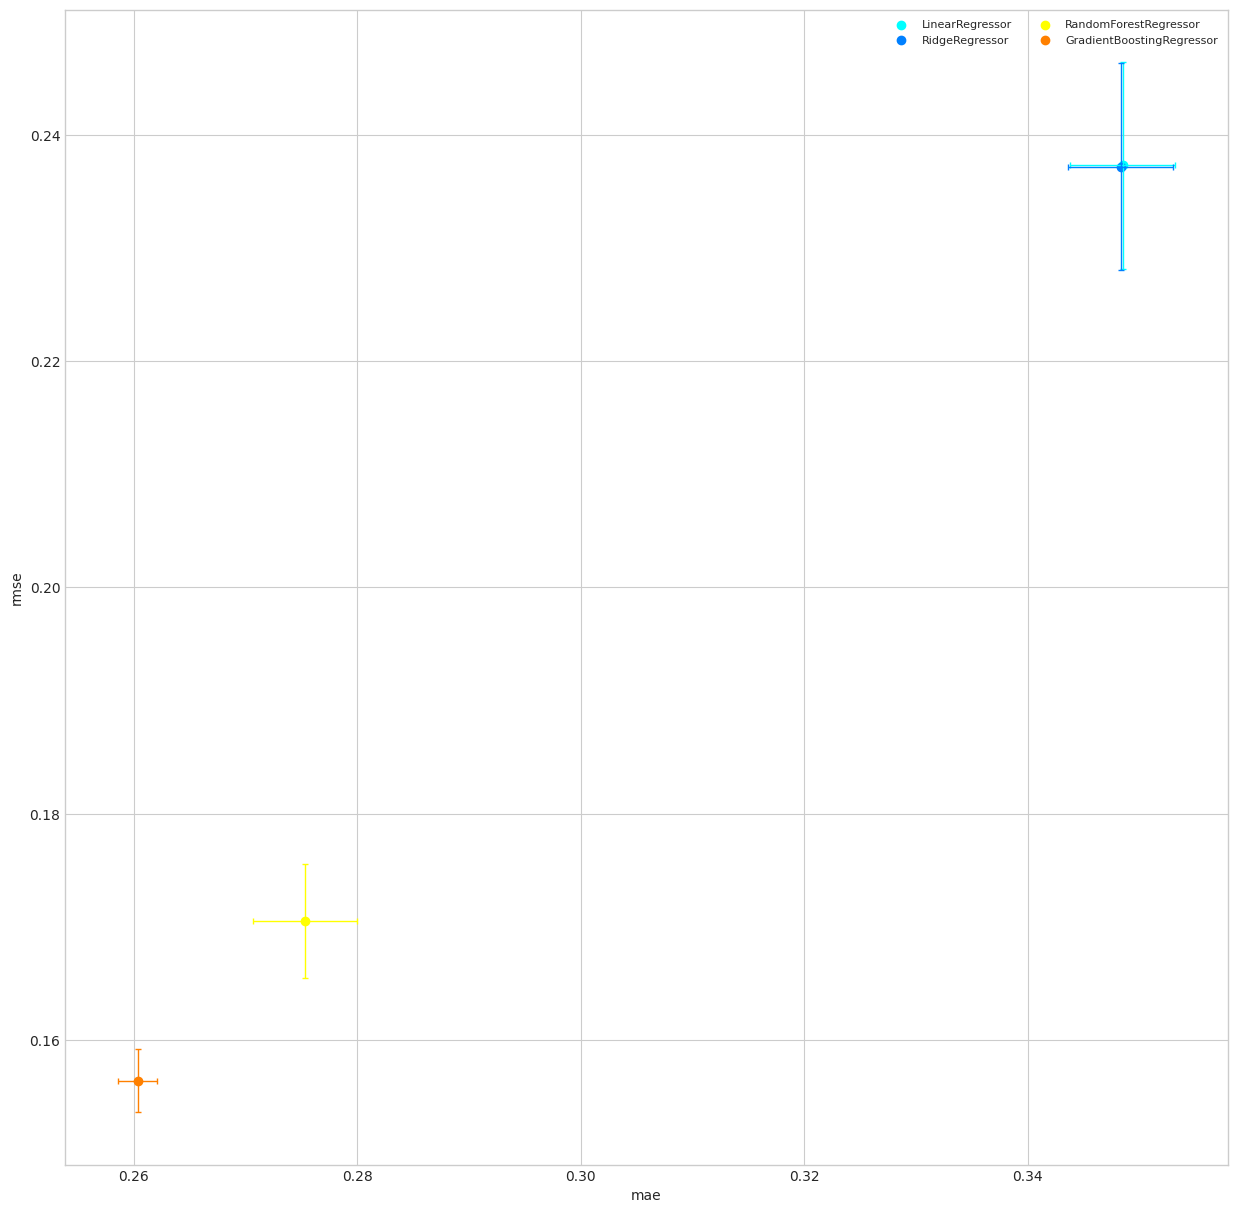

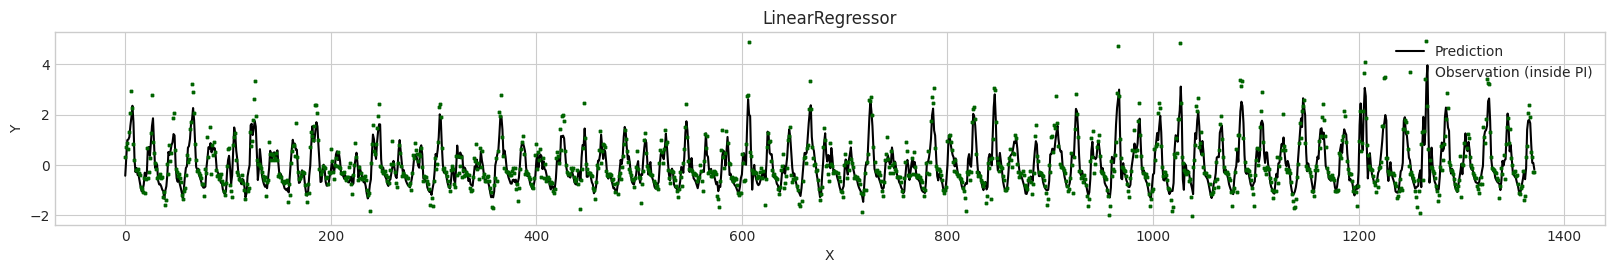

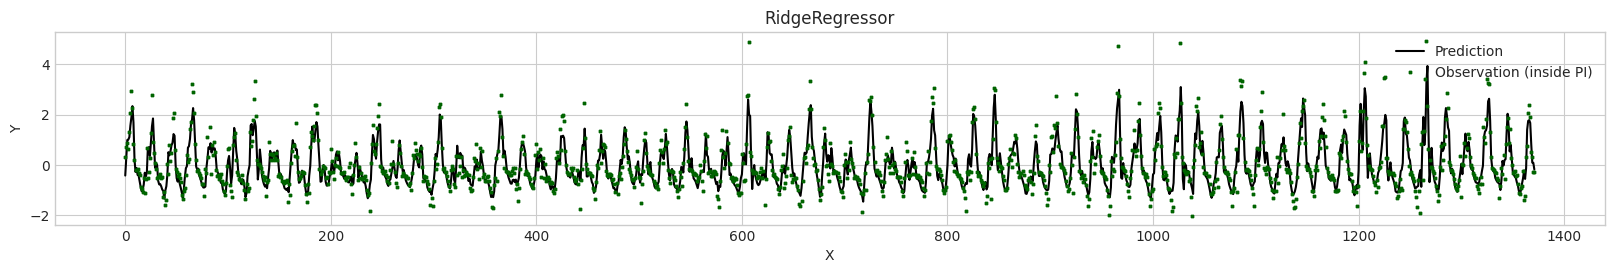

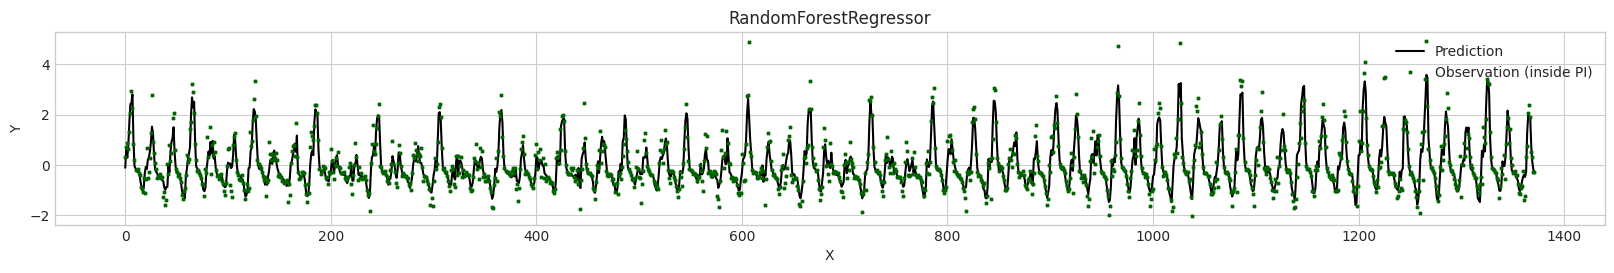

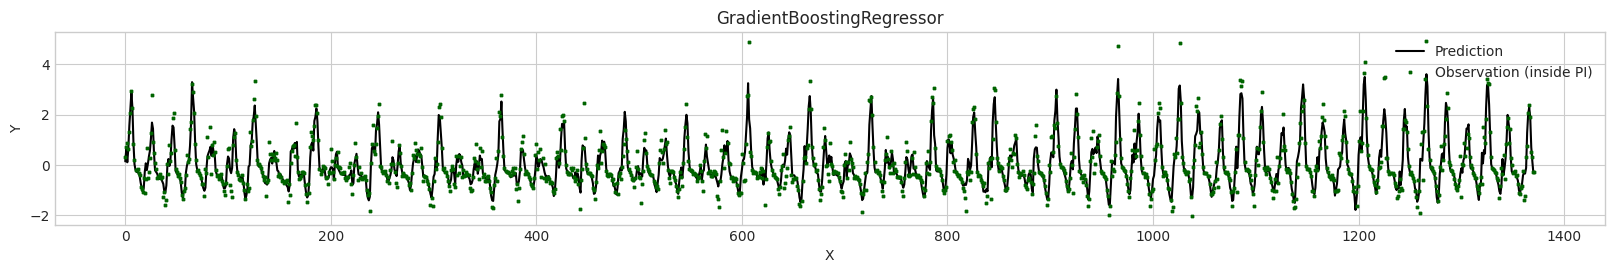

In [130]:
# Agg_plot 
candidates = ['LinearRegressor','RidgeRegressor','RandomForestRegressor','GradientBoostingRegressor']
colors=[[0,1,1],[0,0.5,1],[1,1,0],[1,0.5,0]]

from abench.src.store_API import get_dictperf
from abench.src.Visualisation import scatter_result
Metrics_performance = ['mae','rmse']

dict_perf = get_dictperf(storing,'all')
scatter_result(Metrics_performance, candidates, dict_perf, colors)


# Define Encapsulated-visualisation using stored resultat of benchmark as input.
import matplotlib.pyplot as plt
from abench.src.store_API import get_output,get_AB_loader

def plot_regression(y, output, context, metadata, size, name, **kwarg):

    y_pred = output
    plt.figure(figsize=(size[0], size[1]))
    plt.title(name)
    plt.plot(y_pred, "black", label="Prediction")
    plt.plot(y,
            "darkgreen",
            marker="X",
            markersize=2,
            linewidth=0,
            label="Observation (inside PI)",
            zorder=20)

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend(loc=1)
    plt.show()

from abench.benchmark import plot_curve
storing = 'Benchmark_V0'
component_name = ['LinearRegressor','RidgeRegressor','RandomForestRegressor','GradientBoostingRegressor']
trainset_name = 'syn_[0]'
set_name = 'syn_[1]'
plot_curve(storing, list_component_name, trainset_name, set_name, plot_regression, size=(20, 2.5),plot_param={})


In [119]:
plan_reduced = {'syn_[0]': ['syn_[1]'],'syn_[0 1 2]': ['syn_[3]'], 'syn_[0 1 2 3 4]': ['syn_[5]']}
perf_agg_compute(storing=storing,
                 experiment_plan=plan_reduced,
                 list_component_name=list_component_name,
                 list_metrics=list_metrics,
                 agg_name='reduced')

LinearRegressor mae Train 0.356 ± 0.006 | TEST 0.353 ± 0.01
LinearRegressor rmse Train 0.249 ± 0.009 | TEST 0.248 ± 0.017
RidgeRegressor mae Train 0.356 ± 0.006 | TEST 0.353 ± 0.01
RidgeRegressor rmse Train 0.249 ± 0.009 | TEST 0.248 ± 0.017
RandomForestRegressor mae Train 0.195 ± 0.002 | TEST 0.28 ± 0.009
RandomForestRegressor rmse Train 0.082 ± 0.003 | TEST 0.177 ± 0.008
GradientBoostingRegressor mae Train 0.176 ± 0.003 | TEST 0.262 ± 0.004
GradientBoostingRegressor rmse Train 0.069 ± 0.002 | TEST 0.16 ± 0.004


In [122]:
dict_perf_agg = {}
dict_perf_agg['V0'] = get_dictperf('Benchmark_V0')
dict_perf_agg['V1'] = get_dictperf('Benchmark_V1')

In [129]:
from abench.src.Visualisation import extract_tabular_data, print_flexible_latex_table
data = extract_tabular_data(
    nested_dict=dict_perf_agg,
    row_levels=[0, 1],        # Model, Fold
    col_levels=[2, 3],        # Dataset (Test/Val), Metric (Accuracy/F1)
    value_level='mean_test',
    filter_keys={0: ["V0","V1"],1:["all","reduced"],2: ["LinearRegressor","RidgeRegressor"],3:['mae','rmse']}  # Only extract Accuracy
)

print_flexible_latex_table(data)

\begin{table}[h!]
\centering
\begin{tabular}{|c|c|c|c|c|c|}
\hline
\textbf{Group} & \textbf{Group} & \multicolumn{1}{c}{\textbf{LinearRegressor}} & \multicolumn{1}{c}{\textbf{LinearRegressor}} & \multicolumn{1}{c}{\textbf{RidgeRegressor}} & \multicolumn{1}{c}{\textbf{RidgeRegressor}} \\
\hline
 &  & \textbf{mae} & \textbf{rmse} & \textbf{mae} & \textbf{rmse} \\
\hline
\textbf{V0} & reduced & 0.010095212426251167 & 0.01679860476380159 & 0.010039829543829702 & 0.01682068469915876 \\
\hline
\textbf{V0} & all & 0.009363953769342995 & 0.018265655460574022 & 0.00934629710828809 & 0.018290252258801324 \\
\hline
\textbf{V1} & reduced & 0.010095212426251167 & 0.01679860476380159 & 0.010039829543829702 & 0.01682068469915876 \\
\hline
\textbf{V1} & all & 0.009363953769342995 & 0.018265655460574022 & 0.00934629710828809 & 0.018290252258801324 \\
\hline
\end{tabular}
\caption{Metrics Table}
\label{tab:metrics}
\end{table}
